# 06 – Modern-English baseline (WikiText-2)

**Question:** does autocomplete trained on modern English work on Shakespeare, and vice versa?

**Design**
- WikiText-2 (raw) is preprocessed with the *same rules* as the Shakespeare data (`src/wikitext.py`: NFC/apostrophes, sentences split at `. ! ?`, paragraph end = sentence end, same tokenizer, lowercase, digits → `<num>`; section headings dropped like the ACT/SCENE headers) and loaded with the same loader (`src.data`, `corpus="wikitext"`).
- Its train split is **randomly subsampled (whole sentences, seed 42) to exactly the Shakespeare train token count**, so the comparison is about domain, not data size. Validation and test use the full WikiText-2 splits.
- WikiText has **its own vocabulary** (train only, `min_freq = 2`).
- Models: KN trigram (d tuned on WikiText validation, same grid as before) and the **best Shakespeare LSTM configuration** (512 × 1, dropout 0.5; no tuning; early stopping on WikiText validation), each trained on Shakespeare and on WikiText → 4 models.
- **Disclosure – batch size:** the WikiText LSTM was trained with a batch budget of **2,048 tokens** (at most 128 sentences), the Shakespeare LSTM with **4,096**. WikiText's 25k-word vocabulary makes the logits matrix too large for the 6 GB GPU at 4,096 tokens (the first attempt ran out of memory and was discarded). Model, optimiser (Adam, lr 1e-3), schedule, dropout and early stopping are identical; the smaller batch means about twice as many, noisier optimiser steps per epoch. No hyper-parameter was tuned on either corpus's test set.
- **Cross-evaluation on both test sets.** Perplexity is *not* comparable across vocabularies, so we report top-1/3/5, MRR and KSR plus OOV rates. Scoring uses the **real, unmapped target words** (stage-8 text): the denominator is *all word tokens* (not punctuation, `</s>`, `<num>`), and a target missing from a model's vocabulary is a **miss** (and saves no keystrokes). Consequently the in-domain Shakespeare numbers here are slightly *lower* than in the main results table, which excluded `<unk>` targets.
- Archaic-keyword accuracy is reported on the Shakespeare test set only.

In [1]:
import sys, json, pickle, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data as D, evaluate as E, rnn as R, ngram as N

FIG_DIR, TAB_DIR, MODEL_DIR = ROOT / "figures", ROOT / "tables", ROOT / "models"
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
BLUE, ORANGE, GREEN, GREY = "#0072B2", "#D55E00", "#009E73", "#777777"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")
    print(f"saved figure -> figures/{name}")


def save_table(df, name, index=False):
    df.to_csv(TAB_DIR / name, index=index, encoding="utf-8")
    print(f"saved table  -> tables/{name}")


vs, vw = D.load_vocab(), D.load_vocab(corpus="wikitext")
info = json.loads((D.CORPUS_DIRS["wikitext"] / "info.json").read_text())
sh = {sp: D.read_sentences(sp) for sp in ("train", "val", "test")}
wt = {sp: D.read_sentences(sp, "wikitext") for sp in ("train", "val", "test")}
count = lambda sents: sum(len(s) for s in sents)
unk = lambda sents: sum(t == "<unk>" for s in sents for t in s)
cmp_df = pd.DataFrame([
    {"corpus": c, "split": sp, "sentences": len(d[sp]), "tokens": count(d[sp]),
     "mean_sentence_len": round(count(d[sp]) / len(d[sp]), 1), "pct_unk": round(100 * unk(d[sp]) / count(d[sp]), 2)}
    for c, d in (("Shakespeare", sh), ("WikiText-2 (train subsampled)", wt)) for sp in ("train", "val", "test")])
display(cmp_df)
print(f"vocabulary sizes: Shakespeare {len(vs):,}, WikiText-2 {len(vw):,};  WikiText full train: {info['wikitext_train_full_tokens']:,} tokens -> "
      f"subsampled to {info['wikitext_train_tokens']:,} (= Shakespeare train {info['shakespeare_train_tokens']:,})")
assert info["wikitext_train_tokens"] == info["shakespeare_train_tokens"]
save_table(cmp_df, "baseline_data_summary.csv")
print("\nShakespeare:", " ".join(sh["train"][1000]))
print("WikiText   :", " ".join(wt["train"][1000]))

device: cuda


,corpus,split,sentences,tokens,mean_sentence_len,pct_unk
0,Shakespeare,train,53331,842748,15.8,1.16
1,Shakespeare,val,7857,119916,15.3,2.70
2,Shakespeare,test,7191,101145,14.1,2.81
3,WikiText-2 (train subsampled),train,35862,842748,23.5,2.50
4,WikiText-2 (train subsampled),val,8587,199378,23.2,5.82
5,WikiText-2 (train subsampled),test,9780,223906,22.9,6.83


vocabulary sizes: Shakespeare 14,713, WikiText-2 24,965;  WikiText full train: 1,905,244 tokens -> subsampled to 842,748 (= Shakespeare train 842,748)
saved table  -> tables/baseline_data_summary.csv

Shakespeare: to each of you one fair and virtuous mistress fall , when love please !
WikiText   : by mid <num> , all federal coins , even the base metal cent , had vanished from commerce in much of the country .


## 1. Train the WikiText models
KN trigram: the discount is tuned on **WikiText validation** perplexity (grid {0.5, 0.6, 0.7, 0.75, 0.8, 0.9}). LSTM: `python -m src.train_baseline` (loaded here from `models/wikitext_lstm_h512_l1_d0.5.pt`).

,0,1,2,3,4,5
d,0.50,0.60,0.70,0.75,0.80,0.90
wikitext_val_ppl,253.68,232.52,217.88,212.54,208.44,204.66


WikiText KN-3: tuned discount d = 0.9
saved table  -> tables/baseline_wikitext_kn3_tuning.csv


loaded wikitext_lstm_h512_l1_d0.5 (best epoch 13, val ppl 139.86)
WikiText LSTM: best epoch 13, WikiText val ppl 139.86  (Shakespeare LSTM: best epoch 13, val ppl 99.85; perplexities are NOT comparable across vocabularies)


saved figure -> figures/baseline_wikitext_lstm_curve.png


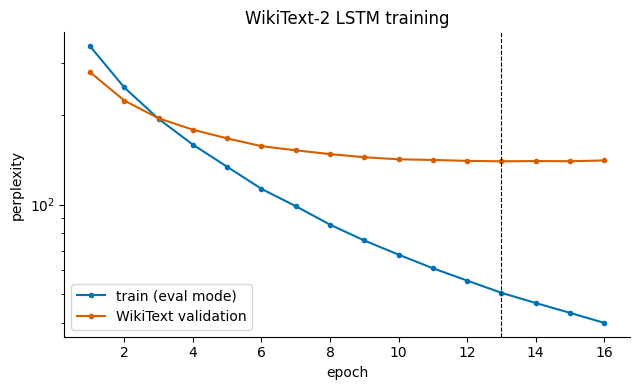

In [2]:
wt_train = D.load_split("train", vocab=vw, corpus="wikitext")
wt_val = D.load_split("val", vocab=vw, corpus="wikitext")
wkn = N.KneserNeyNgram(3, len(vw), vw.bos_id, d=0.75).fit(wt_train)
rows = []
for d in [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]:
    wkn.d = d
    rows.append({"d": d, "wikitext_val_ppl": E.evaluate(wkn, "val", vw, sentences=wt_val, metrics="ppl", log=False)["ppl"]})
tune = pd.DataFrame(rows)
display(tune.round(2).T)
wkn.d = float(tune.loc[tune["wikitext_val_ppl"].idxmin(), "d"])
print("WikiText KN-3: tuned discount d =", wkn.d)
save_table(tune, "baseline_wikitext_kn3_tuning.csv")
pickle.dump(wkn, open(MODEL_DIR / "wikitext_kn3.pkl", "wb"))

cfg_wt = R.default_cfg(cell="lstm", hidden=512, layers=1, dropout=0.5, corpus="wikitext")
wlstm_model, ck_wt = R.train_or_load(cfg_wt, wt_train, wt_val, len(vw), device)
cfg_sh = R.default_cfg(cell="lstm", hidden=512, layers=1, dropout=0.5)
slstm_model, ck_sh = R.load_run(cfg_sh, len(vs), device)
print(f"WikiText LSTM: best epoch {ck_wt['best_epoch']}, WikiText val ppl {ck_wt['best_val_ppl']:.2f}  "
      f"(Shakespeare LSTM: best epoch {ck_sh['best_epoch']}, val ppl {ck_sh['best_val_ppl']:.2f}; perplexities are NOT comparable across vocabularies)")

h = pd.DataFrame(ck_wt["history"])
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(h["epoch"], h["train_ppl_eval"], "o-", color=BLUE, ms=3, label="train (eval mode)")
ax.plot(h["epoch"], h["val_ppl"], "o-", color=ORANGE, ms=3, label="WikiText validation")
ax.axvline(ck_wt["best_epoch"], color="k", ls="--", lw=0.8); ax.set_yscale("log"); ax.legend()
ax.set_xlabel("epoch"); ax.set_ylabel("perplexity"); ax.set_title("WikiText-2 LSTM training")
plt.tight_layout(); save_fig(fig, "baseline_wikitext_lstm_curve.png"); plt.show()

## 2. Cross-evaluation on both test sets (real target words, unmapped text)
The test text is the *unmapped* tokenised text (stage 8): for Shakespeare the sentences of the test works in `data/interim/stage8_lowercased/`, for WikiText `data/interim/wikitext/test_tokens.txt`. Context words unknown to a model become `<unk>`; targets keep their real form.

In [3]:
split_df = pd.read_csv(ROOT / "data" / "split.csv")
sh_test_tokens = []
for slug in split_df.loc[split_df["split"] == "test", "slug"]:      # same work order as data/processed/test.txt (metadata order)
    pass
meta = pd.read_csv(ROOT / "data" / "metadata.csv")
for slug in meta["slug"]:
    if slug in set(split_df.loc[split_df["split"] == "test", "slug"]):
        sh_test_tokens += [l.split() for l in (ROOT / "data" / "interim" / "stage8_lowercased" / f"{slug}.txt").read_text(encoding="utf-8").splitlines() if l.strip()]
wt_test_tokens = [l.split() for l in (ROOT / "data" / "interim" / "wikitext" / "test_tokens.txt").read_text(encoding="utf-8").splitlines() if l.strip()]
assert len(sh_test_tokens) == len(sh["test"]) and all(len(a) == len(b) for a, b in zip(sh_test_tokens, sh["test"]))
print(f"test sets: Shakespeare {len(sh_test_tokens):,} sentences / {count(sh_test_tokens):,} tokens; WikiText {len(wt_test_tokens):,} / {count(wt_test_tokens):,}")

skn = pickle.load(open(MODEL_DIR / "kn3.pkl", "rb"))
models = {("KN trigram", "Shakespeare"): (skn, vs),
          ("LSTM", "Shakespeare"): (R.RNNPredictor(slstm_model, device, name="shakespeare_lstm"), vs),
          ("KN trigram", "WikiText"): (wkn, vw),
          ("LSTM", "WikiText"): (R.RNNPredictor(wlstm_model, device, name="wikitext_lstm"), vw)}
tests = {"Shakespeare": sh_test_tokens, "WikiText": wt_test_tokens}
archaic = E.archaic_set()

rows, details = [], {}
for (arch_name, trained), (model, voc) in models.items():
    for tested, toks in tests.items():
        t0 = time.time()
        r = E.evaluate_unmapped(model, voc, toks, archaic=archaic if tested == "Shakespeare" else None,
                                name=f"{arch_name} / trained on {trained}", details=(tested == "Shakespeare"))
        if "details" in r:
            details[(arch_name, trained)] = r.pop("details")
        r.update({"architecture": arch_name, "trained_on": trained, "tested_on": tested})
        rows.append(r)
        print(f"  {arch_name:10s} trained on {trained:11s} -> {tested:11s}  top-1 {r['top1']:.4f}  top-3 {r['top3']:.4f}  KSR {r['ksr']:.4f}  OOV {r['oov_word_rate']:.3f}  ({time.time() - t0:.0f}s)")
cross = pd.DataFrame(rows)
keep = ["architecture", "trained_on", "tested_on", "n_word_targets", "top1", "top3", "top5", "mrr", "ksr", "oov_word_rate",
        "n_archaic_targets", "archaic_top1", "archaic_top5"]
display(cross[keep].round(4))
save_table(cross[keep], "baseline_cross_eval.csv")

test sets: Shakespeare 7,191 sentences / 101,145 tokens; WikiText 9,780 / 223,906


  KN trigram trained on Shakespeare -> Shakespeare  top-1 0.1218  top-3 0.2171  KSR 0.4507  OOV 0.034  (14s)


  KN trigram trained on Shakespeare -> WikiText     top-1 0.0860  top-3 0.1492  KSR 0.2616  OOV 0.260  (28s)


  LSTM       trained on Shakespeare -> Shakespeare  top-1 0.1340  top-3 0.2398  KSR 0.4702  OOV 0.034  (27s)


  LSTM       trained on Shakespeare -> WikiText     top-1 0.1030  top-3 0.1690  KSR 0.2686  OOV 0.260  (47s)


...

  KN trigram trained on WikiText    -> WikiText     top-1 0.1766  top-3 0.2710  KSR 0.4636  OOV 0.079  (42s)


  LSTM       trained on WikiText    -> Shakespeare  top-1 0.0696  top-3 0.1306  KSR 0.3182  OOV 0.107  (35s)


  LSTM       trained on WikiText    -> WikiText     top-1 0.1908  top-3 0.2938  KSR 0.4896  OOV 0.079  (77s)


,architecture,trained_on,tested_on,n_word_targets,top1,top3,top5,mrr,ksr,oov_word_rate,n_archaic_targets,archaic_top1,archaic_top5
0,KN trigram,Shakespeare,Shakespeare,84068,0.1218,0.2171,0.2747,0.2004,0.4507,0.0338,3715.0,0.0651,0.2164
1,KN trigram,Shakespeare,WikiText,194813,0.0860,0.1492,0.2038,0.1400,0.2616,0.2605,NaN,NaN,NaN
2,LSTM,Shakespeare,Shakespeare,84068,0.1340,0.2398,0.3013,0.2183,0.4702,0.0338,3715.0,0.0985,0.3238
3,LSTM,Shakespeare,WikiText,194813,0.1030,0.1690,0.2165,0.1559,0.2686,0.2605,NaN,NaN,NaN
4,KN trigram,WikiText,Shakespeare,84068,0.0626,0.1199,0.1533,0.1109,0.2988,0.1069,3715.0,0.0008,0.0008
5,KN trigram,WikiText,WikiText,194813,0.1766,0.2710,0.3180,0.2449,0.4636,0.0786,NaN,NaN,NaN
6,LSTM,WikiText,Shakespeare,84068,0.0696,0.1306,0.1676,0.1218,0.3182,0.1069,3715.0,0.0005,0.0008
7,LSTM,WikiText,WikiText,194813,0.1908,0.2938,0.3411,0.2634,0.4896,0.0786,NaN,NaN,NaN


saved table  -> tables/baseline_cross_eval.csv


### In-domain numbers vs the main results table
In the main table, targets that were `<unk>` (outside the train vocabulary) were excluded from the denominator; here they are counted as misses, so the in-domain Shakespeare numbers are slightly lower.

In [4]:
main = pd.read_csv(TAB_DIR / "rnn_test_results.csv").set_index("model")
rows = []
for arch_name, key in (("KN trigram", "KN trigram"), ("LSTM", "LSTM")):
    c = cross[(cross["architecture"] == arch_name) & (cross["trained_on"] == "Shakespeare") & (cross["tested_on"] == "Shakespeare")].iloc[0]
    for m in ("top1", "top3", "ksr"):
        rows.append({"model": arch_name, "metric": m, "main results table": float(main.loc[key, m]), "this notebook (unmapped, OOV = miss)": float(c[m])})
inv = pd.DataFrame(rows)
inv["difference (points)"] = (100 * (inv.iloc[:, 3] - inv.iloc[:, 2])).round(2)
display(inv.round(4))
save_table(inv, "baseline_in_domain_vs_main.csv")

,model,metric,main results table,"this notebook (unmapped, OOV = miss)",difference (points)
0,KN trigram,top1,0.1261,0.1218,-0.43
1,KN trigram,top3,0.2246,0.2171,-0.76
2,KN trigram,ksr,0.4771,0.4507,-2.64
3,LSTM,top1,0.1387,0.1340,-0.47
4,LSTM,top3,0.2482,0.2398,-0.84
5,LSTM,ksr,0.4977,0.4702,-2.75


saved table  -> tables/baseline_in_domain_vs_main.csv


## 3. Figures

saved figure -> figures/baseline_heatmaps.png


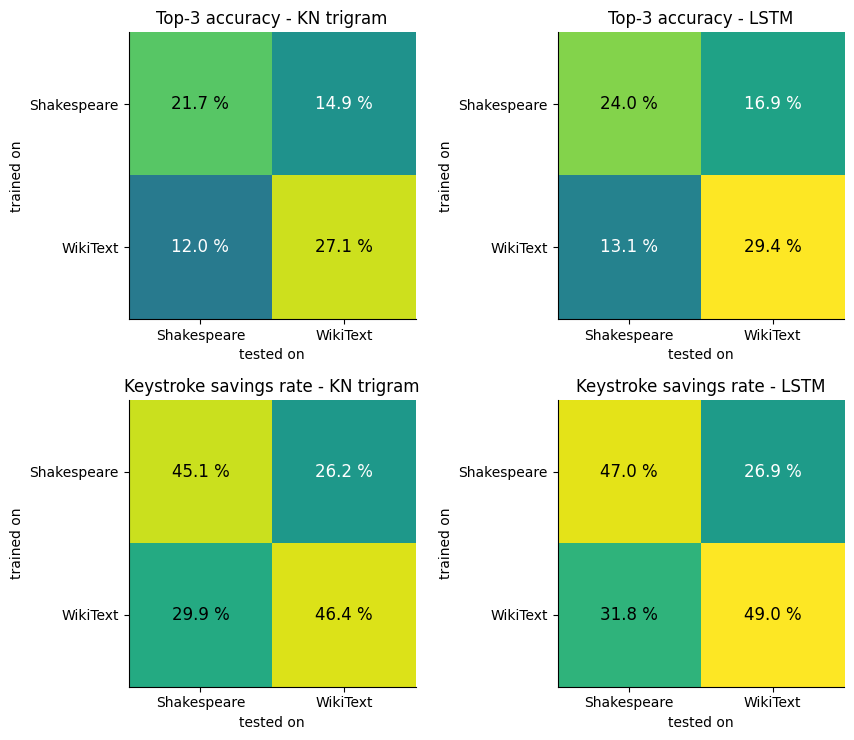

saved figure -> figures/baseline_archaic.png


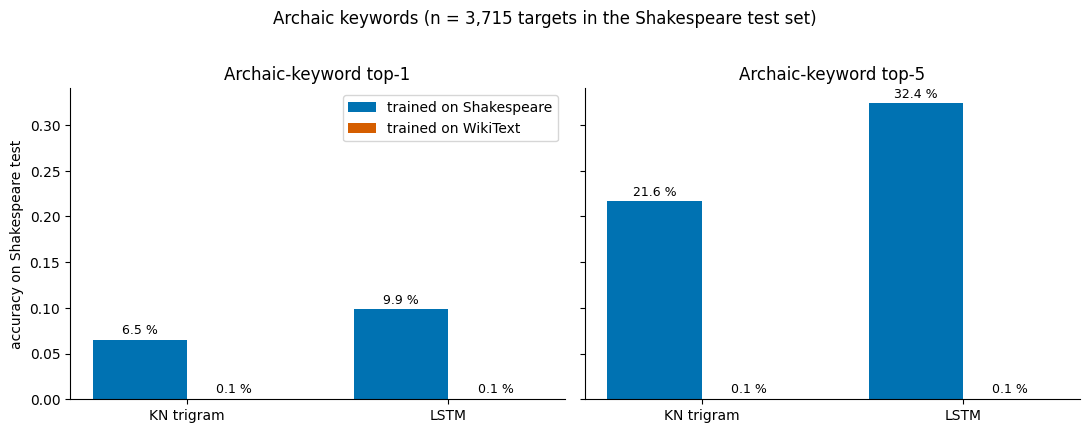

In [5]:
def grid(metric):
    out = {}
    for arch in ("KN trigram", "LSTM"):
        g = cross[cross["architecture"] == arch].pivot(index="trained_on", columns="tested_on", values=metric)
        out[arch] = g.loc[["Shakespeare", "WikiText"], ["Shakespeare", "WikiText"]]
    return out


fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))
for r_i, (metric, ttl) in enumerate((("top3", "Top-3 accuracy"), ("ksr", "Keystroke savings rate"))):
    g = grid(metric)
    vmax = max(v.values.max() for v in g.values())
    for c_i, arch in enumerate(("KN trigram", "LSTM")):
        ax = axes[r_i, c_i]
        im = ax.imshow(g[arch].values, cmap="viridis", vmin=0, vmax=vmax)
        for i in range(2):
            for j in range(2):
                v = g[arch].values[i, j]
                ax.text(j, i, f"{100 * v:.1f} %", ha="center", va="center", color="white" if v < 0.6 * vmax else "black", fontsize=12)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Shakespeare", "WikiText"]); ax.set_yticks([0, 1]); ax.set_yticklabels(["Shakespeare", "WikiText"])
        ax.set_xlabel("tested on"); ax.set_ylabel("trained on"); ax.set_title(f"{ttl} - {arch}")
plt.tight_layout(); save_fig(fig, "baseline_heatmaps.png"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
arch_df = cross[cross["tested_on"] == "Shakespeare"]
x = np.arange(2); w = 0.36
for ax, m, ttl in zip(axes, ("archaic_top1", "archaic_top5"), ("Archaic-keyword top-1", "Archaic-keyword top-5")):
    for off, (trained, color) in zip((-w / 2, w / 2), (("Shakespeare", BLUE), ("WikiText", ORANGE))):
        v = [float(arch_df[(arch_df["architecture"] == a) & (arch_df["trained_on"] == trained)][m].iloc[0]) for a in ("KN trigram", "LSTM")]
        bars = ax.bar(x + off, v, w, color=color, label=f"trained on {trained}")
        ax.bar_label(bars, labels=[f"{100 * t:.1f} %" for t in v], padding=2, fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(["KN trigram", "LSTM"]); ax.set_title(ttl)
axes[0].set_ylabel("accuracy on Shakespeare test"); axes[0].legend()
n_arch = int(arch_df["n_archaic_targets"].iloc[0])
plt.suptitle(f"Archaic keywords (n = {n_arch:,} targets in the Shakespeare test set)", y=1.02)
plt.tight_layout(); save_fig(fig, "baseline_archaic.png"); plt.show()

## 4. Qualitative: Shakespeare LSTM vs WikiText LSTM
The same ten prefixes as `tables/ngram_examples.csv`. The WikiText model cannot suggest a word outside its own vocabulary and sees unknown context words as `<unk>`; the column "in WikiText vocab" says whether the true next word is even available to it.

In [6]:
ex = pd.read_csv(TAB_DIR / "ngram_examples.csv")
pred_s = R.RNNPredictor(slstm_model, device, name="shakespeare_lstm")
pred_w = R.RNNPredictor(wlstm_model, device, name="wikitext_lstm")


def top5(pred, voc, tokens, true):
    ctx = [voc.bos_id] + voc.encode(tokens)
    p = pred.next_word_probs(ctx)
    cand = E.word_ids(voc)
    pc = p[cand]
    top = cand[np.lexsort((cand, -pc))[:5]]
    tid = voc.stoi.get(true)
    rank = None if tid is None else 1 + int((pc > p[tid]).sum() + ((pc == p[tid]) & (cand < tid)).sum())
    return " | ".join(f"{voc.itos[t]} ({p[t]:.2f})" for t in top), rank


rows = []
for _, r in ex.iterrows():
    toks = str(r["prefix"]).split()
    s5, rs = top5(pred_s, vs, toks, r["actual_next"])
    w5, rw = top5(pred_w, vw, toks, r["actual_next"])
    rows.append({"kind": r["kind"], "prefix": " ".join(toks[-9:]), "actual_next": r["actual_next"],
                 "Shakespeare LSTM top-5": s5, "rank_S": rs, "WikiText LSTM top-5": w5, "rank_W": rw,
                 "in WikiText vocab": r["actual_next"] in vw.stoi})
qual = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 300)
display(qual)
save_table(qual, "baseline_examples.csv")

,kind,prefix,actual_next,Shakespeare LSTM top-5,rank_S,WikiText LSTM top-5,rank_W,in WikiText vocab
0,archaic next word,i have seen thee fight when i have envied,thy,my (0.19) | thee (0.11) | the (0.10) | him (0.05) | her (0.04),6,the (0.05) | a (0.04) | to (0.04) | and (0.04) | in (0.03),20568.0,True
1,archaic next word,"alas , poor fool , how have they baffled",thee,here (0.03) | with (0.01) | thus (0.01) | there (0.01) | in (0.01),18,and (0.12) | are (0.08) | or (0.04) | is (0.02) | had (0.01),416.0,True
2,archaic next word,"my lord ,",i'll,i (0.29) | my (0.06) | you (0.05) | we (0.03) | sir (0.03),10,and (0.07) | the (0.05) | who (0.04) | a (0.03) | in (0.02),336.0,True
3,archaic next word,"king's ship , invisible as thou art : there",shalt,is (0.40) | was (0.04) | are (0.04) | art (0.02) | be (0.02),88,is (0.50) | are (0.34) | was (0.05) | were (0.02) | has (0.01),NaN,False
4,archaic next word,'tis one of those odd tricks which,sorrow,i (0.14) | we (0.09) | is (0.07) | he (0.05) | they (0.04),342,was (0.08) | the (0.06) | he (0.05) | is (0.04) | had (0.03),13329.0,True
5,ordinary next word,"you are mad indeed , if you be no",better,more (0.06) | man (0.04) | less (0.03) | matter (0.03) | further (0.02),6,longer (0.05) | more (0.02) | way (0.01) | real (0.01) | doubt (0.01),28.0,True
6,ordinary next word,"john , it will be stinking law , for",his,i (0.07) | the (0.06) | that (0.05) | this (0.03) | they (0.03),13,example (0.31) | the (0.12) | a (0.04) | instance (0.03) | which (0.03),7.0,True
7,ordinary next word,"i visit young ferdinand , whom they suppose is",drown'd,not (0.04) | the (0.01) | but (0.01) | so (0.01) | in (0.01),773,a (0.12) | the (0.07) | not (0.04) | to (0.02) | so (0.02),NaN,False
8,ordinary next word,"prithee , say",on,you (0.23) | i (0.08) | thou (0.06) | what (0.04) | not (0.03),42,that (0.46) | in (0.02) | and (0.02) | to (0.01) | the (0.01),32.0,True
9,ordinary next word,by devilish policy art thou grown great,and,to (0.03) | and (0.02) | men (0.01) | of (0.01) | in (0.01),2,to (0.06) | by (0.05) | and (0.04) | in (0.03) | as (0.02),3.0,True


saved table  -> tables/baseline_examples.csv


## Summary of findings

1. **Matched data:** the WikiText-2 train split was subsampled (random whole sentences, seed 42) to exactly the Shakespeare train size, 842,748 tokens (35,862 sentences of 23.5 tokens on average vs 53,331 of 15.8). Its vocabulary is larger (24,965 vs 14,713 entries) and its validation/test splits are the full ones (199k / 224k tokens, 5.8 % / 6.8 % `<unk>` vs 2.7 % / 2.8 % for Shakespeare).
2. **WikiText models (no extra tuning on Shakespeare):** KN trigram with d = 0.9 tuned on WikiText validation (validation perplexity 204.7, at the edge of the grid); LSTM = the Shakespeare configuration (512 × 1, dropout 0.5), early stopped at epoch 13 (validation perplexity 139.9; not comparable with the Shakespeare numbers because the vocabularies differ).
3. **In-domain (real target words, unknown targets count as misses):** Shakespeare – KN-3 top-1 / top-3 12.2 / 21.7 %, KSR 45.1 %; LSTM 13.4 / 24.0 %, KSR 47.0 %. WikiText – KN-3 17.7 / 27.1 %, KSR 46.4 %; LSTM 19.1 / 29.4 %, KSR 49.0 %. These Shakespeare numbers are 0.4–0.5 points (top-1), 0.8 points (top-3) and 2.6–2.8 points (KSR) below the main results table, because the 3.4 % of word targets that are outside the Shakespeare vocabulary now count as misses instead of being excluded.
4. **Models do not transfer:** top-3 accuracy of the LSTM falls from 24.0 % to 13.1 % when a WikiText-trained model is tested on Shakespeare and from 29.4 % to 16.9 % when a Shakespeare-trained model is tested on WikiText (−11 and −12.5 points, i.e. −45 % and −43 % relative); KN-3 behaves the same (21.7 → 12.0 % and 27.1 → 14.9 %). The LSTM transfers slightly better than KN-3 (top-1 10.3 vs 8.6 % on WikiText, 7.0 vs 6.3 % on Shakespeare), but both lose about half their accuracy.
5. **Keystroke savings collapse even more** (LSTM: 47.0 → 31.8 % for the WikiText model on Shakespeare, 49.0 → 26.9 % for the Shakespeare model on WikiText), mostly because of the vocabulary: 26.0 % of the WikiText word targets are unknown to the Shakespeare vocabulary (10.7 % of the Shakespeare targets are unknown to the WikiText vocabulary, vs 3.4 % / 7.9 % in-domain), and an unknown word can never be suggested.
6. **Archaic words are essentially impossible for the modern models:** on the 3,715 archaic-keyword targets the Shakespeare LSTM reaches top-1 / top-5 = 9.9 / 32.4 % (KN-3 6.5 / 21.6 %), the WikiText LSTM 0.05 / 0.08 % and the WikiText KN-3 0.08 / 0.08 %.
7. **Qualitative:** for *I have seen thee fight when I have envied …* the Shakespeare LSTM ranks *thy* 6th, the WikiText LSTM 20,568th; for *thou art : there …* *shalt* is rank 88 vs not suggested at all. The WikiText model keeps proposing *the / and / a*.
8. **Caveats:** single seed per model; the WikiText test set is 2.2× larger than the Shakespeare one; the two corpora also differ in sentence length, punctuation habits and (for WikiText) no verse; WikiText section headings were dropped and its case map is built from the raw train text; perplexities are intentionally not compared across vocabularies.